# Modify XS data for FF fitting

In [2]:
##Import and Definition
import numpy as np
from math import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
import os, sys, traceback
import matplotlib.gridspec as gridspec

#very import to enable this so the plots can be showed in the page
get_ipython().magic(u'matplotlib inline')

# Use LaTeX font.
plt.rc('text', usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':20})

## Load old Results

In [5]:
##################################################
#fitlines = open('World_CrossSections.dat','r').readlines()
fitlines = open('worlds_crosssections_globfit17.dat','r').readlines()

N = len(fitlines) #exclude the first line which is for the comments
E0 = np.zeros(N,dtype=float)
Theta = np.zeros(N,dtype=float)
Q2 = np.zeros(N,dtype=float)
XS = np.zeros(N,dtype=float)
dXS = np.zeros(N,dtype=float)
TPE_Blun = np.zeros(N,dtype=float)
TPE_Fesh = np.zeros(N,dtype=float)
idat = np.zeros(N,dtype=float)
Norm = np.zeros(N,dtype=float)
#Com = np.zeros(N, dtype=str)

for i in range(1,N):
    values = fitlines[i].split()
    E0[i] = float(values[0])
    Theta[i] = float(values[1])
    Q2[i] = float(values[2])
    XS[i] = float(values[3])
    dXS[i] = float(values[4])
    TPE_Blun[i] = float(values[5])
    TPE_Fesh[i] = float(values[6])
    idat[i] = float(values[7])    
    Norm[i] = float(values[8])    
    #Com[i] = str(fitlines[9:])

    #print 'E0=%f, Theta=%f'%(E0[i], Theta[i])

##Save a copy for cross check
XS_old = np.empty_like(XS)
np.copyto(XS_old, XS)
dXS_old = np.empty_like(dXS)
np.copyto(dXS_old, dXS)

IOError: [Errno 2] No such file or directory: 'worlds_crosssections_globfit17.dat'

## Apply Corrections

### Add 1% sys. err. onto Set#24

In [3]:
dXS_New1 = np.empty_like(dXS)
np.copyto(dXS_New1, dXS)
XS_New1 = np.empty_like(XS)
np.copyto(XS_New1, XS)

for i in range(1,N):
    if abs(idat[i]-24)<0.001:
#        dXS_New1[i] = XS[i] * sqrt( (dXS[i]/XS[i])**2 + 0.01**2 )
        dXS_New1[i] = XS[i] * sqrt( (dXS[i]/XS[i])**2 + 0.00**2 ) ##don't do it this time
        print 'E0=%f, Theta=%f, dxs_old = %f, dxs_new = %f'%(E0[i], Theta[i], dXS_old[i]/XS[i], dXS_New1[i]/XS[i])

NameError: name 'dXS' is not defined

### Extra TPE Correction and uncertaintites for $Q^2>1~GeV^2$:
For $Q^2>1~GeV^2$, the TPE correction onto the cross sections is given as:
   $$\delta^{extra}_{2\gamma } = -0.01 \times (1-\epsilon) \times\frac{ln(Q^2)}{ln(2.2)}, $$
where the virtual photon polarization is defined as:
   $$ \epsilon = [1+2(1+\frac{Q^2}{4M^2})tan^2(\theta/2)]^{-1}$$

Make sure $\delta^{extra}_{2\gamma }$ is negative, so when applying the correction using the following equation, we increase the absolute cross section values by a factor of the absolute 
$\delta^{extra}_{2\gamma }$ value.
   $$\sigma_{new} = (1-\delta^{extra}_{2\gamma })\times \sigma$$
   
The extra TPE uncertainties are assigned to be 2 times of $\delta^{extra}_{2\gamma }$, i.e. 200% uncertainties 

In [4]:
## 

M=0.938272
dXS_New2 = np.empty_like(dXS_New1)
np.copyto(dXS_New2, dXS_New1)
XS_New2 = np.empty_like(XS_New1)
np.copyto(XS_New2, XS_New1)

of = open('worlds_crosssections_globfit17_extra_TPE.dat','w')

outline = '!%8s %8s %8s %12s %12s %8s %8s %4s  %8s %8s'%('E0', 'Theta', 'Q^2', 'Sig', 'dSig_tot', 'TPE(Blun)','TPE(Fesh)', 'idat', 'Norm','TPE(extra)')
print >> of, outline

for i in range(1,N):
    if Q2[i]>1.0:
        eps = (1.0+2.0*(1.0+Q2[i]/4.0/(M**2)) * (tan(Theta[i]/2. * 3.1415926/180.))**2 )**(-1)
        delta_extra = -0.01 * (1-eps) * log(Q2[i])/log(2.2)
  
    else:
        delta_extra = 0.0
 

    XS_New2[i] =XS_New1[i] * (1.0 - delta_extra)
    dXS_New2[i] = XS_New2[i] * sqrt( (dXS_New1[i]/XS_New1[i])**2 + (2.0*delta_extra)**2 )
    #XS_New2[i] =XS_New1[i]
    #dXS_New2[i] =dXS_New1[i]
    
    outline = '%8.2f %8.2f %8.4f %12.4E %12.4E %8.4f %8.4f %4d  %8.3f %8.4f'%(E0[i], Theta[i], Q2[i], XS_New2[i], dXS_New2[i], TPE_Blun[i], TPE_Fesh[i], idat[i], Norm[i],delta_extra)
    print >> of, outline
    if i>N-5:
        print outline
        
    ##Check the values making sense or not:
    if abs(Q2[i]-2.2)<0.1:
        print 'Q2=%8.4f, eps=%8.4e, delta/(1-eps) = %8.4e '%(Q2[i], eps, delta_extra/(1-eps))
        print '--- delta =%8.4f, old err=%8.4f, new err = %8.4f'%(delta_extra, dXS_New1[i]/XS_New1[i]*100., dXS_New2[i]/XS_New2[i]*100. )

    if abs(Q2[i]-4.8)<0.1:
        print 'Q2=%8.4f, eps=%8.4e, delta/(1-eps) = %8.4e '%(Q2[i], eps, delta_extra/(1-eps))
        print '--- delta =%8.4f, old err=%8.4f, new err = %8.4f'%(delta_extra, dXS_New1[i]/XS_New1[i]*100., dXS_New2[i]/XS_New2[i]*100. )

    if abs(Q2[i]-10.6)<1.:
        print 'Q2=%8.4f, eps=%8.4e, delta/(1-eps) = %8.4e '%(Q2[i], eps, delta_extra/(1-eps))
        print '--- delta =%8.4f, old err=%8.4f, new err = %8.4f'%(delta_extra, dXS_New1[i]/XS_New1[i]*100., dXS_New2[i]/XS_New2[i]*100. )


NameError: name 'dXS_New1' is not defined

In [ ]:
print 

### Plotting

NameError: name 'x_s' is not defined

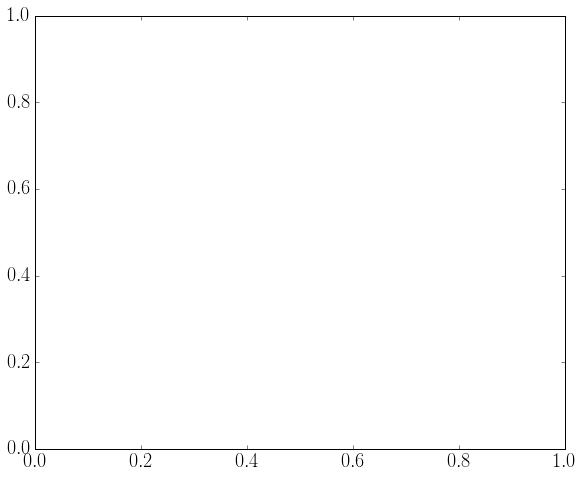

In [5]:
## Plotting Range
xmin = 0.
xmax = 1.
ymin = 1.0
ymax = 7.0
ymin1 = -0.13
ymax1 = 0.13
xmin1 = 4e-2
xmax1 = 0.75

plt.figure(figsize=(24,12))
gs = gridspec.GridSpec(3,3)
gs.update(left=0.07, right=0.99, wspace=0.0)

#######  Subplot for GErat
ax0 = plt.subplot(gs[:2,0])

ax0.errorbar(x_s, Asym_s, yerr=Aerr_s, color='b',fmt='o', label='SoLID')
ax0.errorbar(x_h, Asym_h, yerr=Aerr_h, color='r',fmt='s', label='HERMES')

#ax0.set_xlim(xmin, xmax)
ax0.set_xlim(xmin1, xmax1)

ax0.set_ylabel('$A^{sin(\phi+\phi_{S})}_{UT}$') # label, y-axis
#ax.set_ylim(ymin, ymax)
ax0.set_xscale('log')
ax0.tick_params(axis='both', which='major',labelsize=20)
#ax0.set_xlabel('$x_{B}$') # label, x-axis
ax0.set_xticklabels([])

ax0.set_ylim(ymin1, ymax1)

######  Subplot for GErat
ax1=plt.subplot(gs[2,0])
#ax1.errorbar(x_s, np.array([log(Q2_s[i]) for i in range(0, len(Q2_s))]), yerr=0, color='b',fmt='o', label='HEMES')
#ax1.errorbar(x_h, np.array([log(Q2_h[i]) for i in range(0, len(Q2_h))]), yerr=0, color='b',fmt='o', label='HEMES')
ax1.errorbar(x_h, Q2_h, yerr=0, color='r',fmt='s', label='SoLID')
ax1.errorbar(x_s, Q2_s, yerr=0, color='b',fmt='o', label='SoLID')

ax1.set_ylabel('$Q^{2}$ ($GeV^{2}$)') # label, y-axis
#ax1.set_ylim(ymin, ymax)
ax1.set_xscale('log')
ax1.set_xticklabels([])
ax1.set_xlabel('$x_{B}$') # label, x-axis
ax1.set_xlim(xmin1, xmax1)

ax0.yaxis.set_major_locator(MultipleLocator(0.05))
ax0.yaxis.set_minor_locator(MultipleLocator(0.01))
ax1.yaxis.set_major_locator(MultipleLocator(1.))
ax1.yaxis.set_minor_locator(MultipleLocator(0.5))

ax0.xaxis.set_major_locator(MultipleLocator(0.1))
ax0.xaxis.set_minor_locator(MultipleLocator(0.05))
ax1.xaxis.set_major_locator(MultipleLocator(0.1))
ax1.xaxis.set_minor_locator(MultipleLocator(0.05))

legend = ax0.legend(loc='upper right', shadow='true', fontsize='medium', numpoints=1)
ax0.text(0.06, -0.05, r'$0.3<z<0.4$')
ax0.text(0.06, -0.07, r'$0.3<p_{T}<0.5~GeV/c$')

# plt.show()
#plt.savefig('collins_3he_pip.pdf]')
#}}}

